# Model proposal for continous integration

Here we  show the proposal along with the three outupt:

- estimation of NDVI using exponential decay (L0) 
- linear interpolation of observed deltas (L1)
- smooothing using the LOESS filter with a moving window of 7 deltas (L2)

Here I'll explain how the various steps are done

## Outlier detecion

The outlier detecion will follows this rule

- check if the new observation is inside the bands
- if not, check if **one** extreme condition is met, if so it will be flagged as outlier
- check if the delta delta **and** the distance from the center of the bands are above the threshold, if so it will be flagged as outlier

if there is a pending potential outlier and the incoming data is a true value or a potential outler

- calculate the new delta delta, if it is above the threshold the potential outlier is flagged as outlier and the data is removed

## Estimation

The estimation will be done when no observation are avaible or when the data is flagged as outlier.

The estimation is done based on the alst delta multiplied by the exponential decay

## Linear delta interpolation

The linear deltas interpolation between the lsat and second last observation and it will overwrite the NDVI estimation.

## Smoothing 

To work at best, the data to smooth (so the deltas) has to be in between the smoothing window.

By choosing a window length of 7, we will smooth the fourth value.

The smoothing and L2 writing will be done iteratively between the third and fourth observation in the smoothing window, so between the third and fourth last observation avaible.

It will overwrite the L1 interpolation between the last thrid and fourth observation.


In [15]:
# library loading, nothing interesting
from IPython.display import IFrame, Image, display
import numpy as np
import math
import zarr
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import xarray as xr
import torch
import torch.nn as nn
import pandas as pd
import statsmodels.api as sm
import gc
import imageio
from io import BytesIO
from affine import Affine
from functions import *

The following chunk will prepare the data, to select a different change the value of the pixel in the following chunk, the pixel are numbered according to this table

| Biome                                 | Coordinates (x, y)        | Pixel Range |
|---------------------------------------|---------------------------|-------------|
| Lowland broadleaf                     | 2694491.82, 1126023.20    | 0–24        |
| Highland broadleaf                    | 2692020.28, 1121443.47    | 25–49       |
| Lowland evergreen                     | 2761097.61, 1194613.45    | 50–74       |
| Highland evergreen                    | 2781537.00, 1182975.00    | 75–99       |
| Biscth fire affected area             | 2644008.20, 1133794.76    | 100–124     |
| Biscth fire nearby non-affected area  | 2644328.07, 1134342.81    | 125–149     |
| Drought-affected area                 | 2690025.48, 1287413.03    | 150–174     |
| Burlgim storm affected area           | —                         | 175–199     |

To perform the outlier detection, we need the threshold for the delta delta and distance from the center of the bands, for this reason we run the outlier detection first having access to the full time series and take the threshodl paramter according to the quantiles.

In [16]:
# data loading and raster initialization
# ----- Config -----
zarr_path = "../pixel_biomes_2.zarr/ndvi"

z = zarr.open(zarr_path, mode="r")

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

pixel = 120  # pick one pixel index to check

ndvi_series = z[pixel, :]

# proper sorting

df = pd.DataFrame({
    'date': dates_pd,
    'ndvi': ndvi_series
    })

df_sorted = df.sort_values(by='date')

ndvi_sorted = df_sorted['ndvi'].values

ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.9,0.05])
y_iqr, r_iqr = np.quantile(iqr_param, [0.4, 0.8])


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:115: RuntimeWarning: divide by zero encountered in divide
  iqr_param = np.where(valid_ndvi / median_valid < 1, median_valid / valid_ndvi, valid_ndvi / median_valid)
/home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/functions.py:210: RuntimeWarning: divide by zero encountered in divide
  ratio = np.maximum(valid_ndvi, median_valid) / np.minimum(valid_ndvi, median_valid)


To mimick the continous ingestion, I created a pandas dataframe with date and ndvi (the extra column erves only for the plotting)

In [17]:
# ----- Config -----
zarr_path = "../pixel_biomes.zarr/ndvi"
z = zarr.open(zarr_path, mode="r")

# load seasonal cycle parameters
ds = xr.open_zarr("../../sample_seasonal_cycle_parameter_preds.zarr")

# pick one pixel
ndvi = z[pixel, :]  
dates = ds["dates"].values   # numpy datetime64

# clean and normalize NDVI
ndvi = ndvi.astype(float) / 10000.0
ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

# --- 1. Create initial df ---
df_starting = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi
    })

# --- 2. Handle duplicate dates ---
df_starting = (
    df_starting.groupby("date", as_index=False)
    .mean(numeric_only=True)   # average if duplicates exist
    .set_index("date")
)

# --- 3. Reindex to full daily series ---
full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
df = df_starting.reindex(full_index)

# add forecast column for later use
df["forecast"] = np.nan
df["upper"] = np.nan
df["lower"] = np.nan
df["gapfilled"] = np.nan
df["outlier"] = False
df["delta_smoothed"] = np.nan
df["idx"] = np.arange(len(df))
df["deltas_L1"] = np.nan


df.index.name = "date"

# remove data veofre marh 2018
df = df.loc[df.index >= pd.Timestamp("2018-04-25")]


/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


Here we use the function, it requires 
-The 6 parameters to perform the outlier detection
- two date: one for the last observation, one for the potential outlier (if present)
- an array (of dates or delta) to perfrom the window smoothing

The writing and reading of data are illustrated inside the function.

In [18]:
# --- run your function row by row ---
# need an inital condition
last_date =  None #pd.Timestamp("2018-04-25")
last_potential_date =None
deltas_arr = []
dates_delta_arr = []
# this is extra just for the plotting
latency = []
current_date_latency = []

for date in df.index[df.index >= pd.Timestamp("2018-04-26")]:
    last_date, last_potential_date_arr, deltas_arr, dates_delta_arr, latency,  current_date_latency = ndvi_continous_final_2(
        df=df,
        date=date,
        params_lower =  params_lower[[91]],
        params_upper =  params_upper[[91]],
        last_date=last_date,
        deltas_arr = deltas_arr,
        dates_delta_arr = dates_delta_arr,
        last_potential_date = last_potential_date,
        y_delta_l = y_delta_l, 
        y_delta_h = y_delta_h,
        r_delta_h = r_delta_h, 
        r_delta_l = r_delta_l,
        y_iqr= y_iqr, 
        r_iqr = r_iqr,
        tau = 45,
        smoothing_values = 7,
        latency = latency,
        current_date_latency = current_date_latency

    )


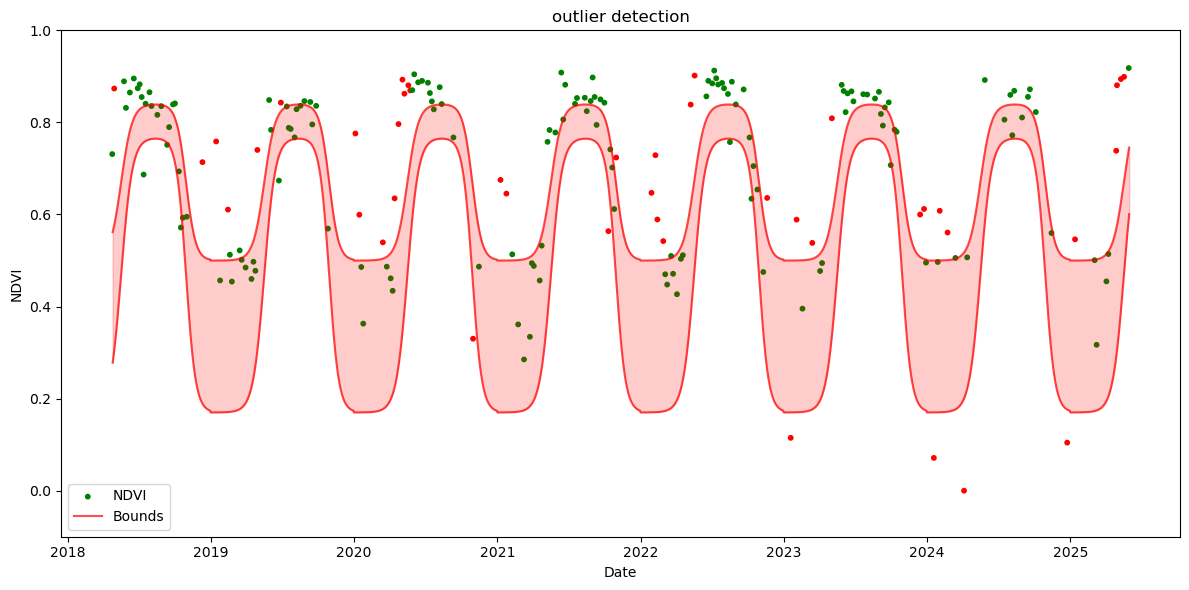

In [19]:

# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

# NDVI as green points
color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("outlier detection")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()



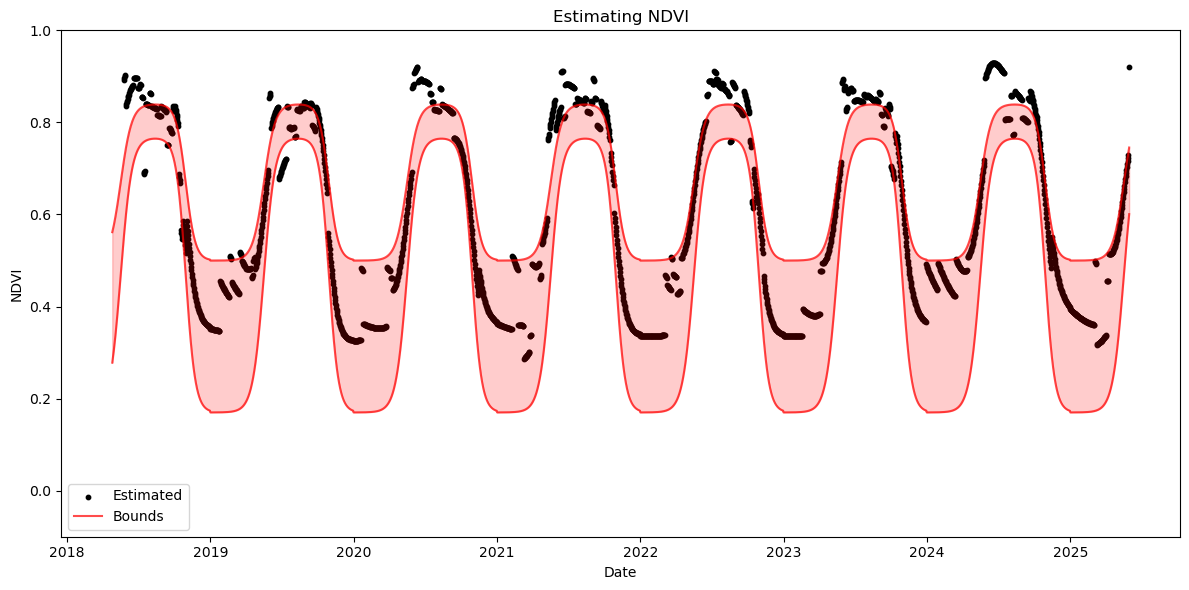

In [20]:

# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

#ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.scatter(df_plot.index, df_plot["forecast"], color='black', label='Estimated', s=10)
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("Estimating NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

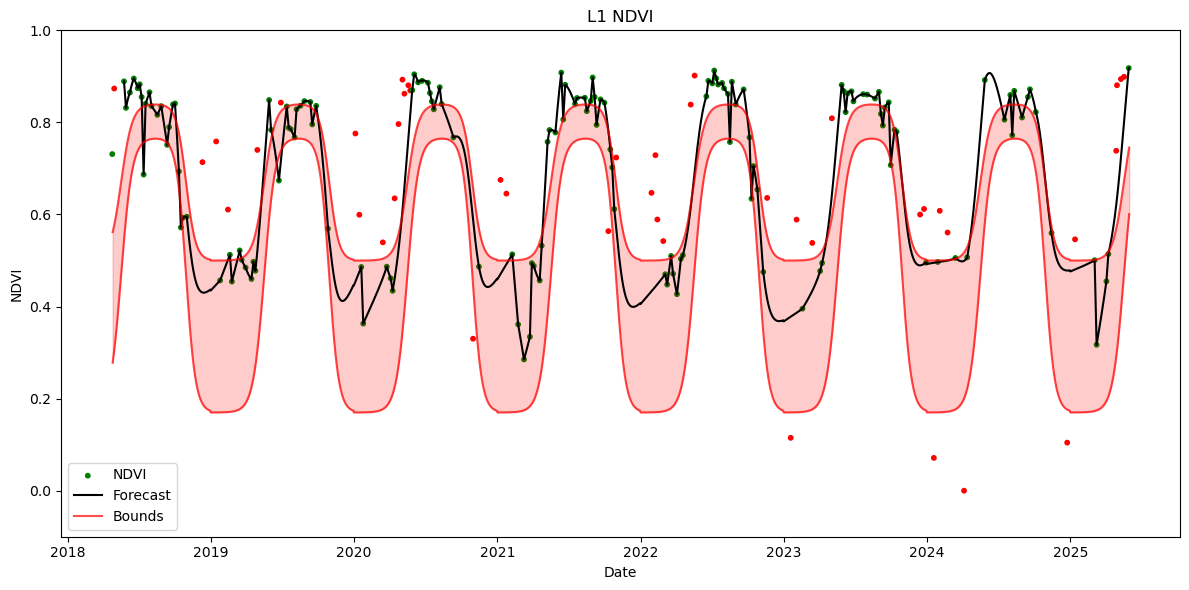

In [21]:
# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["deltas_L1"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Forecast')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("L1 NDVI")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

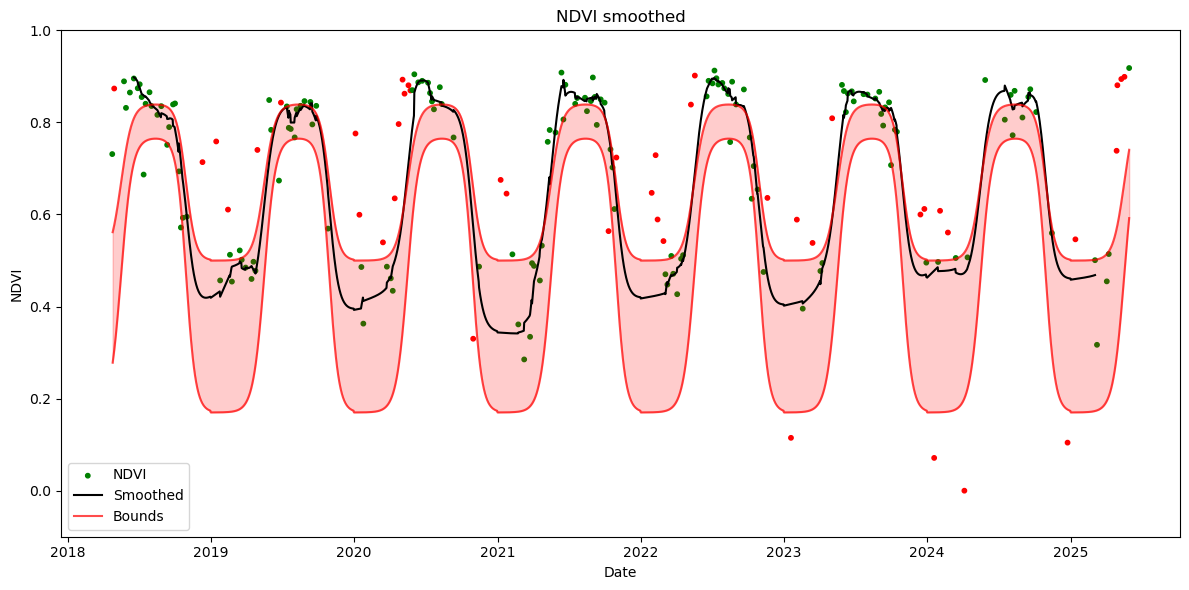

In [22]:
# Select a date range if needed

# Crop df_plot to that date
df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

fig, ax = plt.subplots(figsize=(12, 6))

color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

# Forecast as black points
ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

ax.set_title("NDVI smoothed")
ax.set_ylim(-0.1, 1.0)
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

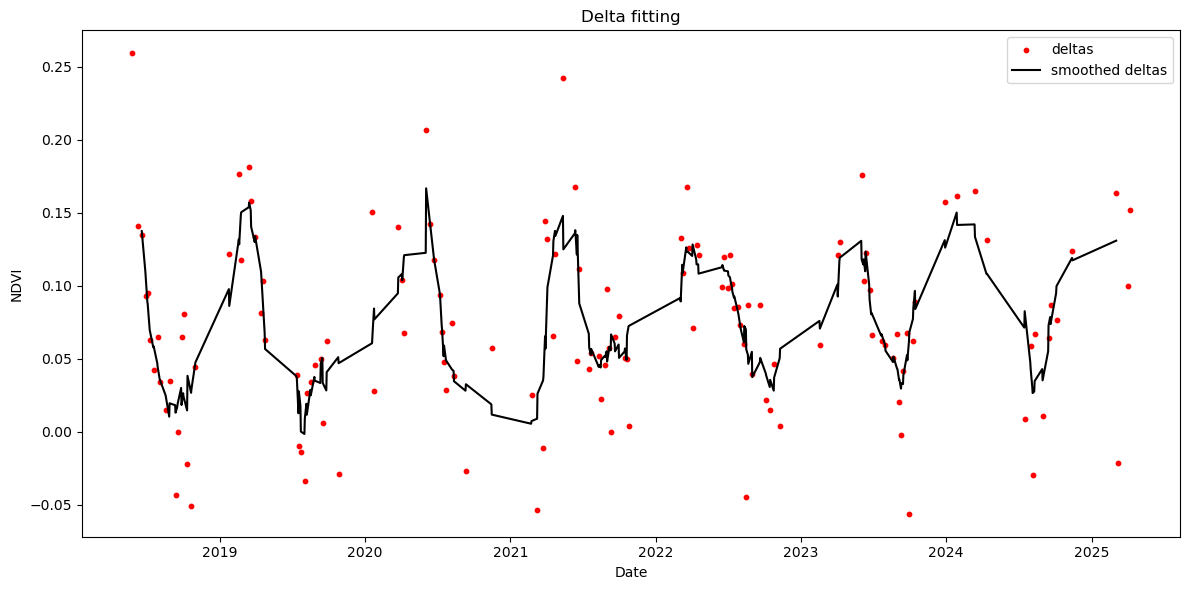

In [23]:
# Select a date range if needed
df_plot = df[df.index >= "2018-04-20"]
mask = (df["deltas"].notna()) & (df["outlier"] == False)


fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.scatter(df_plot.index, df_plot["deltas"], label = "deltas",color='red', s= 10)
ax.plot(df_plot.index, df_plot["delta_smoothed"], label = "smoothed deltas", color='black')


ax.set_title("Delta fitting")
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.legend()
plt.tight_layout()

With this method, we have a nice smoothing but the latency can be quite high, especially during winter

/tmp/ipykernel_1028154/3483122546.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


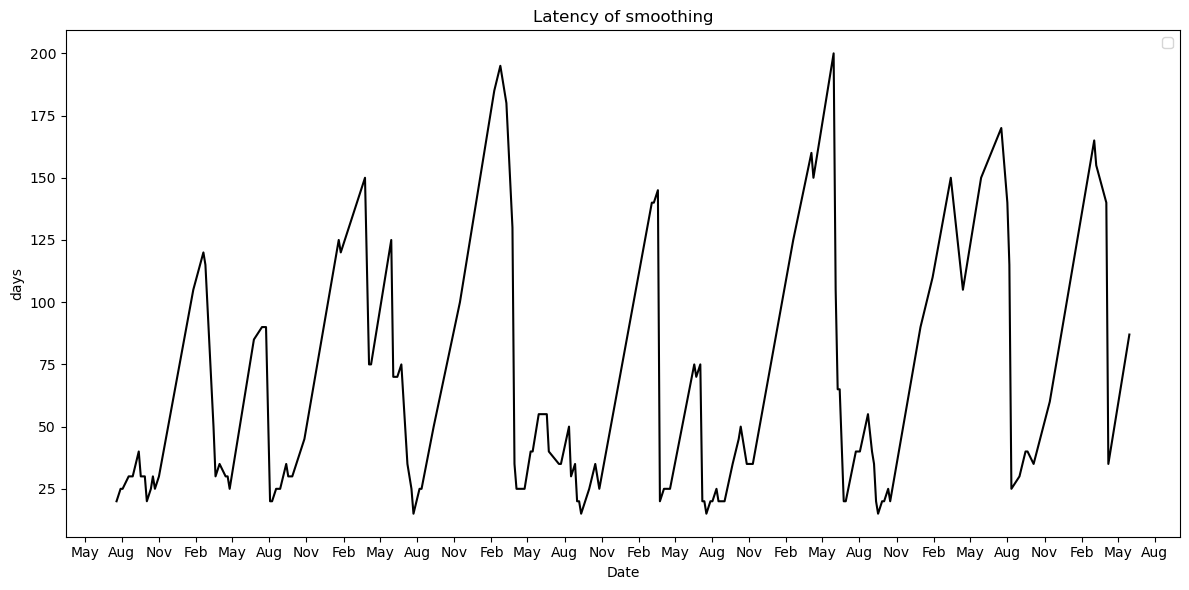

In [24]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 6))

# Forecast as black points
ax.plot(current_date_latency, latency, color="black")

# Format x-axis to show ticks every 3 months with month names only
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Latency of smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("days")
ax.legend()
plt.tight_layout()
plt.show()
